Select CSV file...


Saving student_performance_300_realistic.csv to student_performance_300_realistic.csv
File loaded successfully.


,previous_grade,attendance_days,assignments_score_0_10,quiz_score_0_10,study_hours,participation,final_grade
0,73,15,6.1,6.4,3.1,1,87
1,65,13,7.8,7.2,2.1,4,91
2,83,22,7.6,8.4,2.2,3,100
3,96,14,9.5,9.2,3.0,1,100
4,66,14,6.8,7.6,1.4,5,88



Cleaned Data (first 5 rows):


,previous_grade,attendance_days,assignments_score_0_10,quiz_score_0_10,study_hours,participation,final_grade
0,73,15,6.1,6.4,3.1,1,87
1,65,13,7.8,7.2,2.1,4,91
2,83,22,7.6,8.4,2.2,3,100
3,96,14,9.5,9.2,3.0,1,100
4,66,14,6.8,7.6,1.4,5,88


Cleaned data shape: (300, 7)

Features used for training:
['previous_grade', 'attendance_days', 'assignments_score_0_10', 'quiz_score_0_10', 'study_hours', 'participation']

Train shape: (240, 6)
Test shape: (60, 6)

Model Evaluation:
MAE : 2.36
MSE : 10.93
RMSE: 3.31
R²  : 0.84


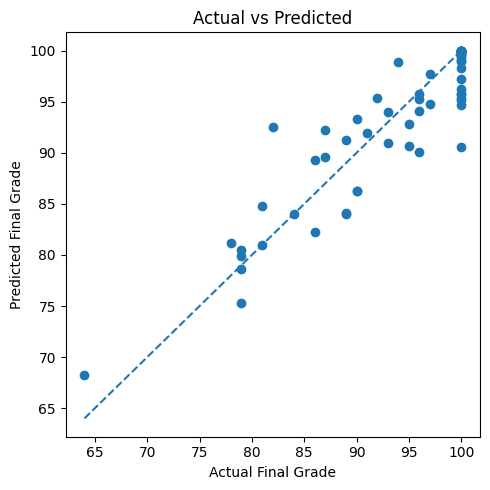

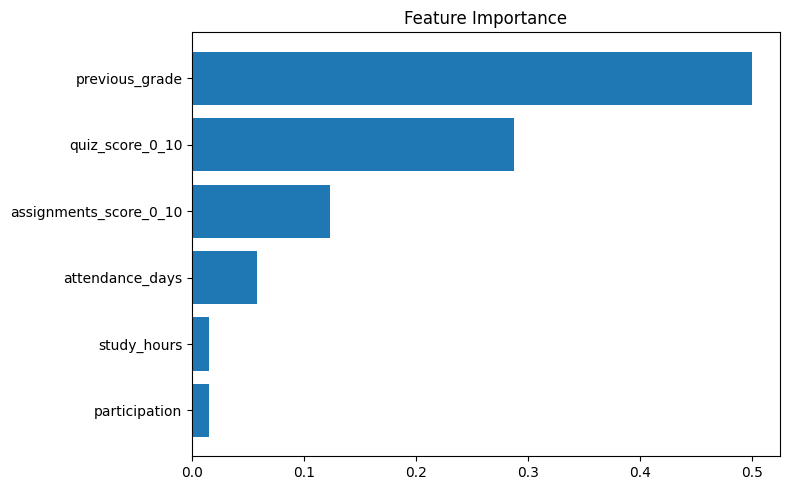


Feature importance values:
previous_grade: 0.5003
quiz_score_0_10: 0.2874
assignments_score_0_10: 0.1235
attendance_days: 0.0584
study_hours: 0.0154
participation: 0.0150


In [ ]:
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Select CSV file...")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[file_name]))
print("File loaded successfully.")
display(df.head())


df = df.drop_duplicates()

df = df.dropna()


numeric_cols = [
    "previous_grade",
    "attendance_days",
    "assignments_score_0_10",
    "quiz_score_0_10",
    "study_hours",
    "participation",
    "final_grade"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")


df = df.dropna(subset=numeric_cols)


df = df[
    (df["previous_grade"].between(0, 100)) &
    (df["attendance_days"].between(0, 30)) &
    (df["assignments_score_0_10"].between(0, 10)) &
    (df["quiz_score_0_10"].between(0, 10)) &
    (df["study_hours"].between(0, 10)) &
    (df["participation"].between(0, 10)) &
    (df["final_grade"].between(0, 100))
]


df = df.reset_index(drop=True)

print("\nCleaned Data (first 5 rows):")
display(df.head())
print("Cleaned data shape:", df.shape)

TARGET_COLUMN = "final_grade"

X = df.drop(columns=[TARGET_COLUMN])
y = df[TARGET_COLUMN]

print("\nFeatures used for training:")
print(X.columns.tolist())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTrain shape:", X_train.shape)
print("Test shape:", X_test.shape)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
model.fit(X_train_s, y_train)

y_pred = model.predict(X_test_s)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Evaluation:")
print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²  : {r2:.2f}")

plt.figure(figsize=(5,5))
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "--")
plt.xlabel("Actual Final Grade")
plt.ylabel("Predicted Final Grade")
plt.title("Actual vs Predicted")
plt.tight_layout()
plt.show()

importances = model.feature_importances_
features = X.columns
idx = np.argsort(importances)[::-1]

plt.figure(figsize=(8,5))
plt.barh(range(len(features)), importances[idx][::-1])
plt.yticks(range(len(features)), features[idx][::-1])
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

print("\nFeature importance values:")
for i in range(len(features)):
    print(f"{features[idx[i]]}: {importances[idx[i]]:.4f}")